In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import math

d:\Jon\Uni\SYproject\embeddedSys\.venv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [3]:
SAMPLES = 2000
SEED = 1337
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [4]:
x_val = np.random.uniform(low = 0, high = 4*math.pi, size = SAMPLES)

In [5]:
np.random.shuffle(x_val)

In [6]:
y_val = np.cos(x_val)

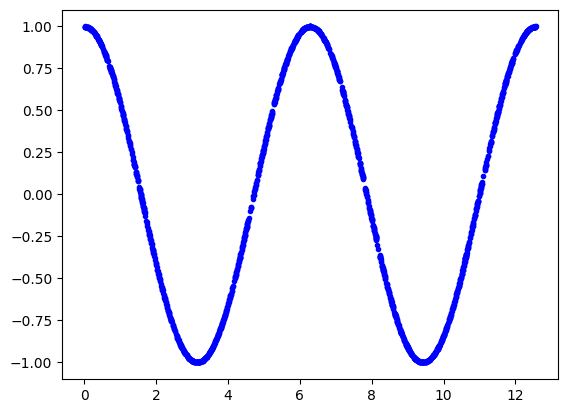

In [7]:
plt.plot(x_val, y_val, 'b.')
plt.show()

In [8]:
# Adding random noise to the y values
y_val += 0.1 * np.random.randn(*y_val.shape)

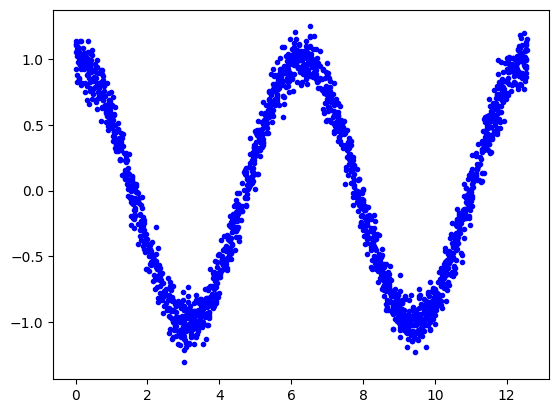

In [10]:
plt.plot(x_val, y_val, 'b.')
plt.show()

In [12]:
# Train-test split
train_split = int(0.6 * SAMPLES)
test_split = int(0.2*SAMPLES + train_split)

In [13]:
# use np.split to chop our data into three parts
x_train, x_validate, x_test = np.split(x_val, [train_split, test_split])
y_train, y_validate, y_test = np.split(y_val, [train_split, test_split])

In [14]:
# Double check that our splits add up correctly
assert (x_train.size + x_validate.size + x_test.size) == SAMPLES

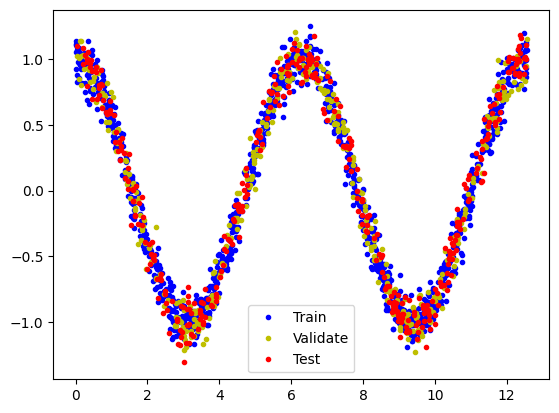

In [15]:
# Plot the data in each partition in different colours
plt.plot(x_train, y_train, 'b.', label='Train')
plt.plot(x_validate, y_validate, 'y.', label='Validate')
plt.plot(x_test, y_test, 'r.', label='Test')
plt.legend()
plt.show()

In [17]:
# use keras to create simple model architecture
from tensorflow.keras import layers
model_1 = tf.keras.Sequential()

In [18]:
# First layer takes scalar input and feeds it through 16 neurons
# The neurons use the relu activation function
model_1.add(layers.Dense(16, activation='relu', input_shape=(1,)))

d:\Jon\Uni\SYproject\embeddedSys\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
# 2nd (Final) layer takes the 16 outputs and produces a single output
model_1.add(layers.Dense(1))

In [22]:
# Compile the model using standard optimiser and loss function for regression
model_1.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])
# Print a summary of the model's architecture
model_1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49 (196.00 B)

 Trainable params: 49 (196.00 B)

 Non-trainable params: 0 (0.00 B)

In [23]:
history_1 = model_1.fit(x_train, y_train, epochs=100, batch_size=16, validation_data=(x_validate, y_validate))

Epoch 1/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 1.2560 - mae: 0.9117 - val_loss: 0.5304 - val_mae: 0.6513
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5131 - mae: 0.6400 - val_loss: 0.5253 - val_mae: 0.6511
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5118 - mae: 0.6395 - val_loss: 0.5240 - val_mae: 0.6504
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5110 - mae: 0.6393 - val_loss: 0.5230 - val_mae: 0.6498
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5104 - mae: 0.6391 - val_loss: 0.5221 - val_mae: 0.6492
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5098 - mae: 0.6388 - val_loss: 0.5213 - val_mae: 0.6488
Epoch 7/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5092 - mae: 0.6386 - val_loss: 0.5207 - val_mae: 0.6483
Epoch 8/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5087 - mae: 0.6383 - val_loss: 0.5200 - val_mae: 0.6480
Epoch 9/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.508

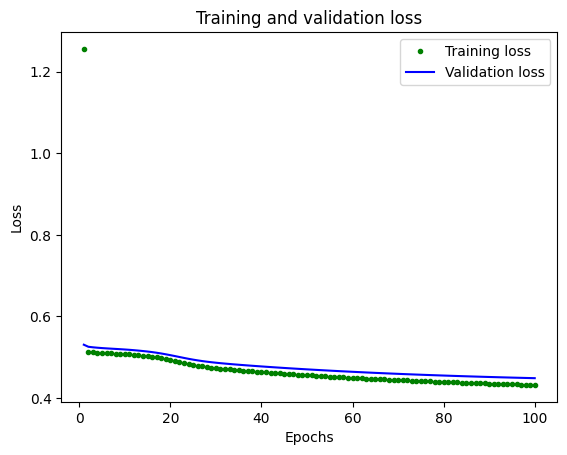

In [25]:
loss = history_1.history['loss']
val_loss = history_1.history['val_loss']
epochs = range(1, len(loss) + 1)

plt.plot(epochs, loss, 'g.', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

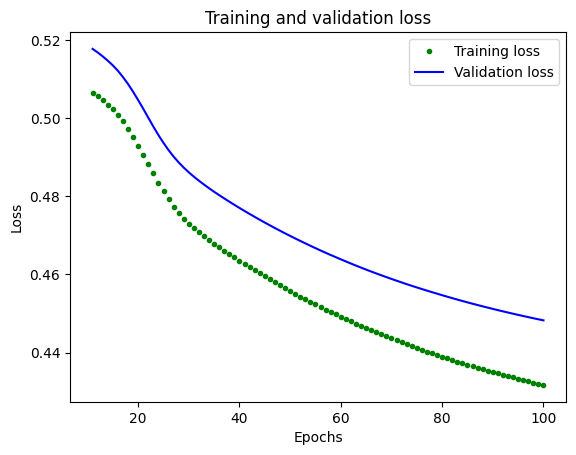

In [28]:
SKIP = 10

plt.plot(epochs[SKIP:], loss[SKIP:], 'g.', label='Training loss')
plt.plot(epochs[SKIP:], val_loss[SKIP:], 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

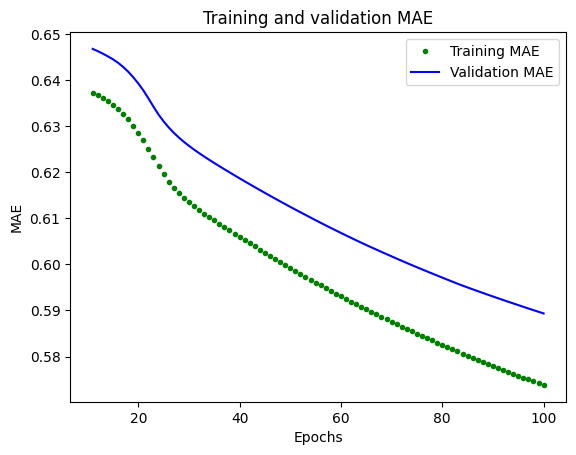

In [30]:
mae = history_1.history['mae']
val_mae = history_1.history['val_mae']

plt.plot(epochs[SKIP:], mae[SKIP:], 'g.', label='Training MAE') 
plt.plot(epochs[SKIP:], val_mae[SKIP:], 'b', label='Validation MAE')
plt.title('Training and validation MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.show()

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4716 - mae: 0.6014 
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


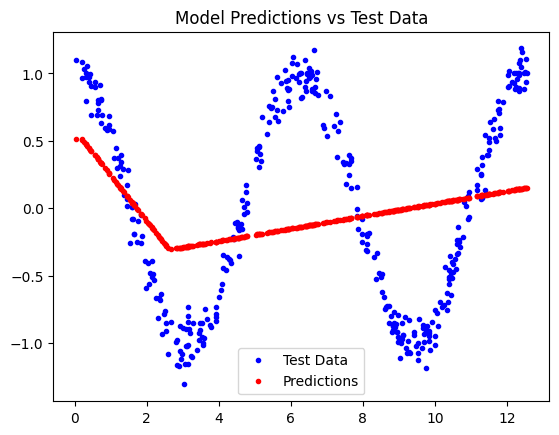

In [33]:
# Calculate and print loss on our test dataset
loss = model_1.evaluate(x_test, y_test)

# use model to make predictions from our test data
predictions = model_1.predict(x_test)
# plot the predictions along with the test data
plt.clf()
plt.title('Model Predictions vs Test Data')
plt.plot(x_test, y_test, 'b.', label='Test Data')
plt.plot(x_test, predictions, 'r.', label='Predictions')
plt.legend()
plt.show()

In [35]:
# Create a new model with more layers
model_2 = tf.keras.Sequential()
model_2.add(layers.Dense(16, activation='relu', input_shape=(1,)))

model_2.add(layers.Dense(16, activation='relu'))
model_2.add(layers.Dense(1))
model_2.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])
model_2.summary()

d:\Jon\Uni\SYproject\embeddedSys\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 16)             │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
# train the new model
history_2 = model_2.fit(x_train, y_train, epochs=100, batch_size=16, validation_data=(x_validate, y_validate))

Epoch 1/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2528 - mae: 0.3842 - val_loss: 0.2554 - val_mae: 0.3956
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2477 - mae: 0.3786 - val_loss: 0.2495 - val_mae: 0.3889
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2429 - mae: 0.3732 - val_loss: 0.2444 - val_mae: 0.3830
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2382 - mae: 0.3679 - val_loss: 0.2397 - val_mae: 0.3775
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2336 - mae: 0.3629 - val_loss: 0.2352 - val_mae: 0.3723
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2292 - mae: 0.3578 - val_loss: 0.2297 - val_mae: 0.3658
Epoch 7/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2248 - mae: 0.3531 - val_loss: 0.2254 - val_mae: 0.3609
Epoch 8/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2204 - mae: 0.3482 - val_loss: 0.2211 - val_mae: 0.3558
Epoch 9/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.216

In [ ]:
# Convert the model to the TensorFlow Lite format w/o quantisation
converter = tf.lite.TFLiteConverter.from_keras_model(model_2)
tflite_model = converter.convert()

# Save the model to disk
open("model_2.tflite", "wb").write(tflite_model)

# Convert the model to the TensorFlow Lite format w quantisation
converter = tf.lite.TFLiteConverter.from_keras_model(model_2)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
# Define a representative dataset generator function
def representative_data_gen():
    for value in x_test:
        # Each scalar value inside a 2D array that is wrapped in a list
        yield [np.array(value, dtype=np.float32, ndmin =2)]

converter.representative_dataset = representative_data_gen
# convert the model
tflite_model_2 = converter.convert()

# Save the model to disk
open("model_2_quant.tflite", "wb").write(tflite_model_2)

INFO:tensorflow:Assets written to: C:\Users\JONATH~1\AppData\Local\Temp\tmpy1uraou_\assets


INFO:tensorflow:Assets written to: C:\Users\JONATH~1\AppData\Local\Temp\tmpy1uraou_\assets


Saved artifact at 'C:\Users\JONATH~1\AppData\Local\Temp\tmpy1uraou_'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1), dtype=tf.float32, name='keras_tensor_4')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  2123406302608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2123406301264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2123406309328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2123406305680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2123406307792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2123406303952: TensorSpec(shape=(), dtype=tf.resource, name=None)
INFO:tensorflow:Assets written to: C:\Users\JONATH~1\AppData\Local\Temp\tmppgpzp2in\assets


INFO:tensorflow:Assets written to: C:\Users\JONATH~1\AppData\Local\Temp\tmppgpzp2in\assets


Saved artifact at 'C:\Users\JONATH~1\AppData\Local\Temp\tmppgpzp2in'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1), dtype=tf.float32, name='keras_tensor_4')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  2123406302608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2123406301264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2123406309328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2123406305680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2123406307792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2123406303952: TensorSpec(shape=(), dtype=tf.resource, name=None)


d:\Jon\Uni\SYproject\embeddedSys\.venv\Lib\site-packages\tensorflow\lite\python\convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


3736

d:\Jon\Uni\SYproject\embeddedSys\.venv\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


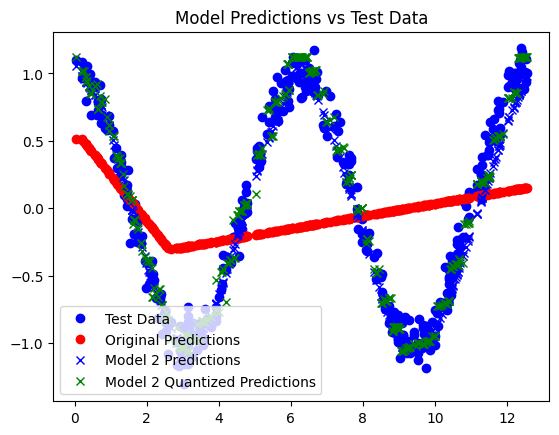

In [43]:
# Instantiate a TFLite interpreter for each model
intpret_model_2 = tf.lite.Interpreter(model_path="model_2.tflite")
intpret_model_2_quant = tf.lite.Interpreter(model_path="model_2_quant.tflite")

# allocate memory for the models
intpret_model_2.allocate_tensors()
intpret_model_2_quant.allocate_tensors()

# Get indexes of input and output tensors for both models
input_index_2 = intpret_model_2.get_input_details()[0]['index']
output_index_2 = intpret_model_2.get_output_details()[0]['index']
input_index_2_quant = intpret_model_2_quant.get_input_details()[0]['index']
output_index_2_quant = intpret_model_2_quant.get_output_details()[0]['index']

# create arrays to hold predictions
model_2_preds = []
model_2_quant_preds = []

for value in x_test:
    # create 2D tensor wrapping the current x value
    x_val_tensor = tf.convert_to_tensor([[value]], dtype=np.float32)
    # write the value to the input tensor
    intpret_model_2.set_tensor(input_index_2, x_val_tensor)
    # run inference
    intpret_model_2.invoke()
    # read the output tensor
    model_2_preds.append(intpret_model_2.get_tensor(output_index_2)[0][0])
    # now do the same for the quantized model
    intpret_model_2_quant.set_tensor(input_index_2_quant, x_val_tensor)
    intpret_model_2_quant.invoke()
    model_2_quant_preds.append(intpret_model_2_quant.get_tensor(output_index_2_quant)[0][0])


# plot the predictions along with the test data
plt.clf()
plt.title('Model Predictions vs Test Data')
plt.plot(x_test, y_test, 'bo', label='Test Data')
plt.plot(x_test, predictions, 'ro', label='Original Predictions')
plt.plot(x_test, model_2_preds, 'bx', label='Model 2 Predictions')
plt.plot(x_test, model_2_quant_preds, 'gx', label='Model 2 Quantized Predictions')
plt.legend()
plt.show()